In [1]:
import numpy as np
from matplotlib import pyplot as plt 
import random
import imageio.v3
import os
from tqdm import tqdm
import matplotlib.colors as mcolors
plt.style.use('bmh')

In [40]:
#Exercise 1
#Defining the RG flow constants
def Kdot(K):
    return np.log(np.cosh(2*K))/2
def g(K):
    return np.log(2)/2 + np.log(np.cosh(2*K))/4
KappaArray,gArray = [1], []

In [41]:
for i in range(6):
    newK = Kdot(KappaArray[-1])
    KappaArray.append(newK)
    gArray.append(newK)

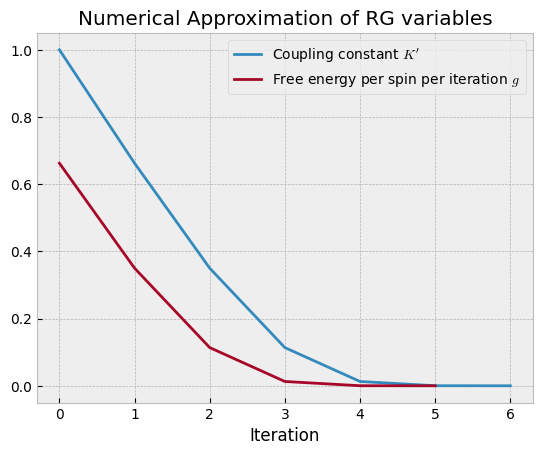

In [42]:
plt.plot(KappaArray, label=r'Coupling constant $K^\prime$ ')
plt.plot(gArray,label = r'Free energy per spin per iteration $g$')
plt.title('Numerical Approximation of RG variables')
plt.xlabel('Iteration')
plt.legend()

In [5]:
# As we can easily see the limits of both series is towards zero K. That is due to the fact
# that the point K is a stable attractive point for the system

In [43]:
# b) From the lectures we know

def freeEnergyRG(array):
    sumVar = 0
    for index,g in enumerate(array):
        sumVar += 2** (-index) * g
    return sumVar

def freeEnergyTrue(K):
    return np.log(2*np.cosh(K))

In [48]:
print(f"For the RG approximatation we get {freeEnergyRG(gArray):0.3f}, whilst the true result is : {freeEnergyTrue(KappaArray[0]):0.3f}")

For the RG approximatation we get 0.868, whilst the true result is : 1.127


In [ ]:
# There is a bit of mismatch between the results, but it is to be expected as
# 1) We have not performed many iterations
# 2) We are far away from a stable point, which would guarantee faster convergence

In [6]:
#Exercise 2 Computer simulation of the Ising model
# a)
# Helpfull functions
def generateStartingPopulation(Nx,Ny):
    return np.random.choice([1, -1], size=(Nx, Ny)) #Thank God numpy has that command

def pickRandomPosition(Nx,Ny):
    return (np.random.randint(0, Nx), np.random.randint(0, Ny))

def computeEnergyChange(i,j,Nx,Ny,population):
    # This is a bit tricky to implement due to the boundary conditions, but we march forward
    # The way we are gonna do this is generate an array of all the positions the algo should check
    # This approach allows for an elegant implementation of the periodic bounds, with the modulo operator
    checkArray = [  ( (i-1) % (Nx), j)  , #Left of center
                    ( (i+1) % (Nx), j)  , #Right of center
                    ( i, (j-1) % (Ny) ) , #Down of center
                    ( i, (j+1) % (Ny) )   #Up of center
                ]
    #The reason we take the size of each lattice dimension, is because arrays start counting at 0, not 1
    changeInEnergy = 0
    for neighbour in checkArray:
        changeInEnergy += + population[i][j]* population[neighbour[0]][neighbour[1]] #If we did the spin flip
    return 2*changeInEnergy # DE = E_f - E_i = 2* E_f



def runSimulation(startPopulation,temperature, stepsMC):
    Nx, Ny = len(startPopulation[0]), len(startPopulation)
    N, MagnetizationArray, populations = Nx * Ny, [], []
    population = startPopulation
    for index in range(stepsMC):
        for step in range(N):
            i,j = pickRandomPosition(Nx,Ny)
            energyChange = computeEnergyChange(i,j, Nx, Ny,population)
            if energyChange <= 0 or (np.random.uniform(0,1) <= np.exp(-energyChange / temperature) ):
                population[i][j] = population[i][j] * (-1) 
        MagnetizationArray.append(np.sum(population)/N)
        populations.append(np.copy(population))
    return np.array(MagnetizationArray),populations


In [7]:
# The Monte Carlo simulation favors motion to an equilibrium, by immediately flipping the spins in order to drive
# the system into a lower energy state. Also, it allows for small deviations from such a state, by employing
# random flipping, so as to ensure that the system explores more areas of the phase space, that may lead to more 
# optimal solutions. In that regard, by having a computationally cheap function that penalizes states the more
# energy it would take for them to flip, it guarantees a balance between exploration and exploitation 
# of the phase space optima.

In [8]:
# b)
# The Monte Carlo simulation is a probabilistic numerical approach to evaluating efficiently large phase spaces. As per the law of large numbers and the central limit theorem, the
# random guess the simulation returns must at some point resemble a Gaussian distribution with mean μ and variance σ. Therefore, we get a result with
# relative error, σ/(μ * sqrt(N)). That means we expect the results we get to scale better with accuracy O(sqrt(N)). As we need large numbers relative to the dimensions of the grid,
# we expect to get that above O(1000).

In [9]:
stepsIntervals = [100,200,300,500,1000,1500,2000,2500,3000,5000,10000]
lowTempResults = [np.average(runSimulation(generateStartingPopulation(32,32),1,step)[0]) for step in stepsIntervals]
highTempResults = [np.average(runSimulation(generateStartingPopulation(32,32),3,step)[0]) for step in stepsIntervals]

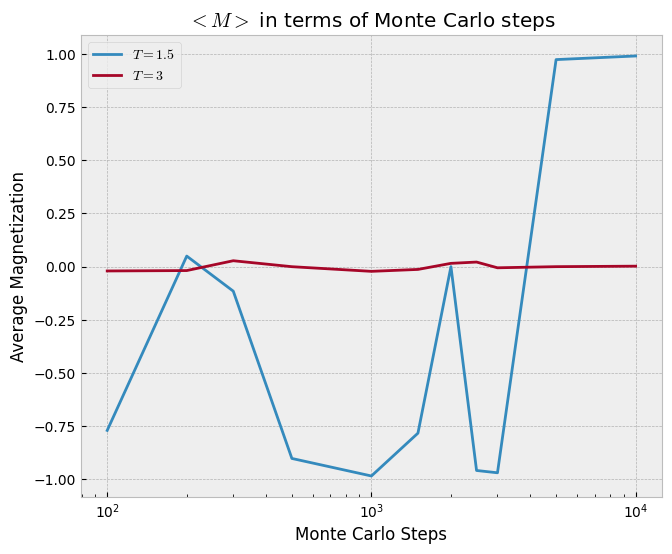

In [10]:
plt.figure(figsize=(7.5, 6), dpi=100)
plt.plot(stepsIntervals,lowTempResults, label=rf'$T = 1.5$ ')
plt.plot(stepsIntervals,highTempResults, label=rf'$T = 3$ ')
plt.legend()
plt.xlabel('Monte Carlo Steps')
plt.ylabel('Average Magnetization')
plt.title(r'$<M>$ in terms of Monte Carlo steps')
plt.xscale('log')
plt.show()

In [11]:
# As it can be seen, the Monte Carlo approach converged rather nicely for the high-temperature case,
# but shows chaotic behaviors inherent in the low-temperature system. Nevertheless,
# after enough steps, it manages to converge to the proper result.

In [12]:
def createGIF(simulation, temperature, M):
    cmap = plt.cm.coolwarm
    bounds = [-1, 0, 1]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # List to store generated frames
    frames = []

    for i, (data,m) in enumerate(zip(simulation,M)):
        # Create a figure
        fig, ax = plt.subplots()
        im = ax.imshow(data, cmap=cmap, norm=norm)
        ax.set_title(rf"$<M> = {m:0.5f} $ , $T = {temperature:0.2f}$")
        ax.set_xlabel("X-axis")
        ax.set_ylabel("Y-axis")
        ax.invert_yaxis()
        plt.colorbar(im, ax=ax, label="Spin")

        # Save frame to a temporary file
        temp_filename = f"frame_{i}.png"
        plt.savefig(temp_filename)
        frames.append(temp_filename)
        plt.close(fig)

    # Create GIF from frames
    gif_filename = f"GIF_for_T_{temperature:0.2f}.gif"
    with imageio.get_writer(gif_filename, mode="I", duration=0.5) as writer:
        for frame in frames:
            image = imageio.v3.imread(frame)
            writer.append_data(image)
            os.remove(frame)
    print("GIF saved as output.gif")
    pass

In [13]:
#Running the simulation for all the different temperatures of interest
# c)
Tarray = np.linspace(0.5,3,30)
TempsToGIF = [T for T in Tarray]
magnetizationTotalArray, gifSave = [], []
for T in tqdm(Tarray):
    magnetizationArray, populations = runSimulation(generateStartingPopulation(32,32),T,3000)
    if T in TempsToGIF:
        gifSave.append(populations)
    magnetizationTotalArray.append(magnetizationArray)

100%|██████████| 30/30 [11:41<00:00, 23.38s/it]


In [14]:
# TempsToGIF = [Tarray[0],Tarray[-1],Tarray[5],Tarray[10]]
# for T, p, m in zip(TempsToGIF,gifSave, magnetizationTotalArray):
#     createGIF(p,T, m)
# Taking GIFS of all the different temperatures

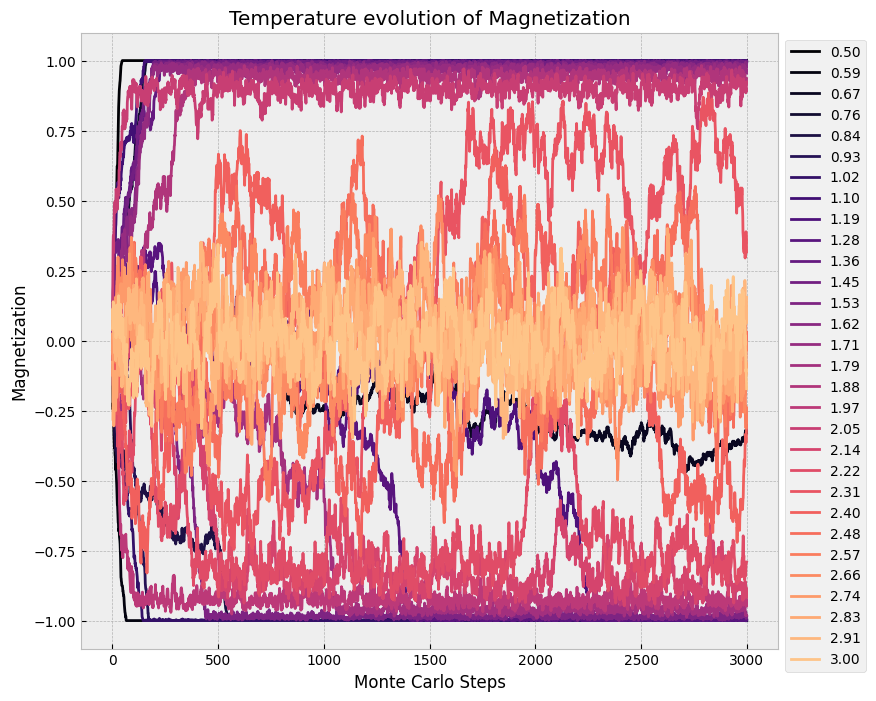

In [15]:
cmap = plt.get_cmap('magma')

# Normalize the index to be between 0 and 1 for the colormap
norm = plt.Normalize(vmin=0, vmax=len(magnetizationTotalArray)+3)
plt.figure(figsize=(9, 8), dpi=100)
for index, (magnetization, temp) in enumerate(zip(magnetizationTotalArray, Tarray)):
    color = cmap(norm(index))
    plt.plot(magnetization, label=f'{temp:.2f}', color=color)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Monte Carlo Steps')
plt.ylabel('Magnetization')
plt.title('Temperature evolution of Magnetization')
plt.show()

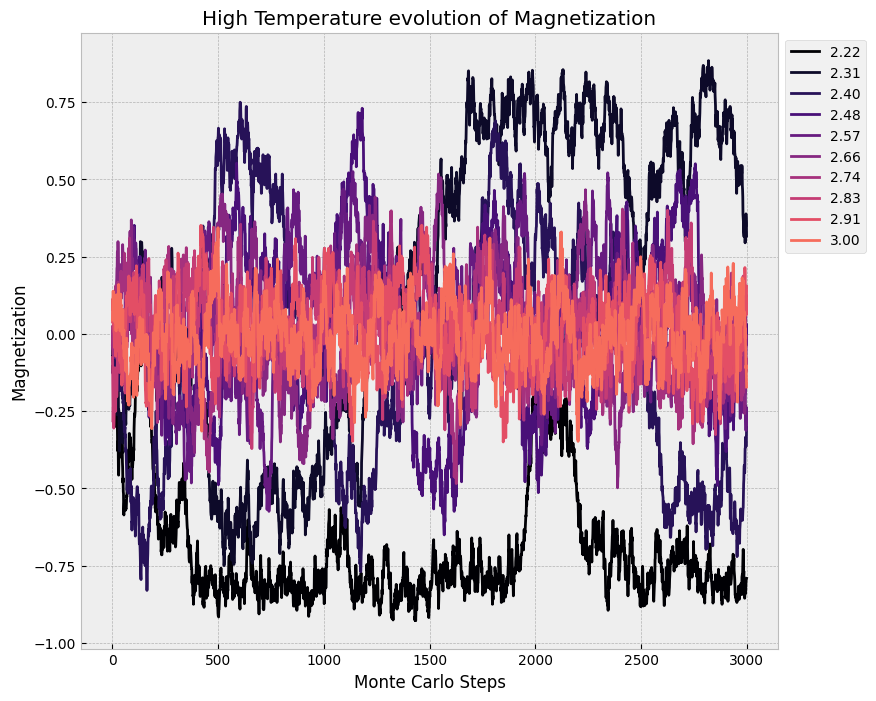

In [18]:
cmap = plt.get_cmap('magma')

# Normalize the index to be between 0 and 1 for the colormap
norm = plt.Normalize(vmin=0, vmax=len(magnetizationTotalArray[20::])+3)
plt.figure(figsize=(9, 8), dpi=100)
for index, (magnetization, temp) in enumerate(zip(magnetizationTotalArray[20::], Tarray[20::])):
    color = cmap(norm(index))
    plt.plot(magnetization, label=f'{temp:.2f}', color=color)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Monte Carlo Steps')
plt.ylabel('Magnetization')
plt.title('High Temperature evolution of Magnetization')
plt.show()

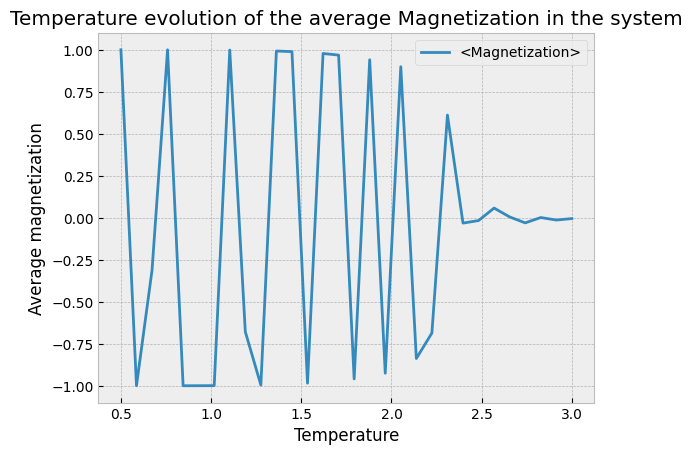

In [57]:
averages = [np.average(m[1500:]) for m in magnetizationTotalArray] # We take measurements after 1500 ie MonteCarloTotalSteps/2 so that our system has time to settle down
plt.plot(Tarray,averages,label='<Magnetization>')
plt.xlabel('Temperature')
plt.ylabel('Average magnetization')
plt.title('Temperature evolution of the average Magnetization in the system')
plt.legend()
plt.show()

In [58]:
# For the high-temperature regime, the spin orientation is dominated by random fluctuations
# that result in the system having no preference in the number of up or down spins.
# Thus, the total magnetization is zero.
# For the low-temperature regime, the magnetic field of the different areas and particles dominates
# the system interactions. The system urgently wants to find a stable energy. In doing so, any
# starting island or majority of spins dominates the dynamics, and the system ends up either at 1, -1, or 0.
# Our graph truly encapsulates such behavior, and we can confidently confirm that the Monte Carlo
# simulation is an accurate representation of the Ising model in 2D.

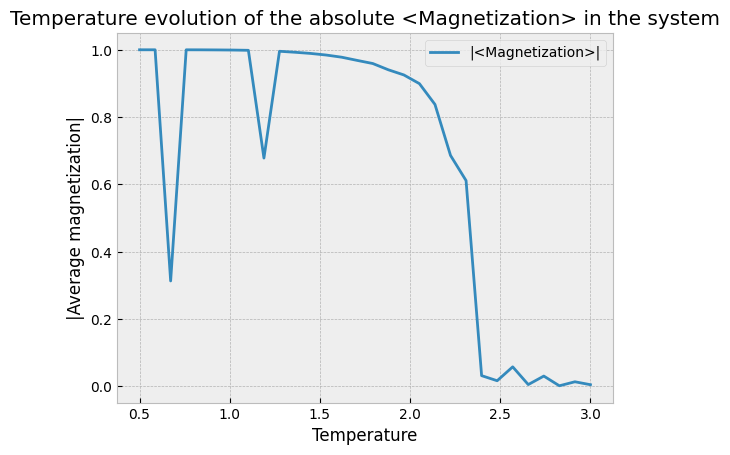

In [55]:
plt.plot(Tarray,np.abs(averages),label='|<Magnetization>|')
plt.xlabel('Temperature')
plt.ylabel('|Average magnetization|')
plt.title('Temperature evolution of the absolute <Magnetization> in the system')
plt.legend()
plt.show()

In [59]:
# Clearly our system has a phase transition at temperature of around 2.25 as was expected from the 2D Ising model

# You can find the full code and some interesting GIFs at https://github.com/grk38/Theoretical-Statistical-Mechanics-11/tree/main